In [15]:
import pandas as pd
DYN_RESULTS=pd.read_csv('../CODE_EXPERIMENT/my_survey_static/interaction_events.csv')

In [16]:
DYN_RESULTS.columns

Index(['time', 'seed', 'event', 'user_id', 'user_stance', 'user_partition',
       'ranking', 'num_rank', 'num_news', 'news_stance', 'highlight',
       'in_this_session'],
      dtype='object')

In [17]:
# PTR[2][1][1]

In [18]:
PTR = {
    parameter: {
        t: {
            r: DYN_RESULTS[
                DYN_RESULTS['seed'].map(str) == f"{parameter}{r}{t}"
            ].sort_values(by='time', ascending=True).tail(200)
            for r in range(1, 3+1)
        }
        for t in range(1, 4+1)
    }
    for parameter in [1, 2]
}

In [19]:
import numpy as np

def clicks_to_extremism(df_slice):
    return np.abs(df_slice['news_stance']).mean()

def clicks_to_polarization(df_slice):
    left_clicks=df_slice[df_slice['user_partition']==-1]
    right_clicks=df_slice[df_slice['user_partition']==1]

    left_mean=0
    right_mean=0
    if len(left_clicks):
        left_mean=left_clicks['news_stance'].mean()
    if len(right_clicks):
        right_mean=right_clicks['news_stance'].mean()

    return right_mean-left_mean


In [20]:
import random

In [21]:
random.choice([1,2,3])

2

In [22]:
from scipy.stats import mannwhitneyu


In [23]:
# settings
TOPIC=1
BLOCK_SIZE=200

def MW_EP(TOPIC, BLOCK_SIZE):
    assert 200%BLOCK_SIZE==0

    N_SAMPLES_PER_REP=int(200//BLOCK_SIZE)
    # WINDOW_MIN=200-BLOCK_SIZE

    E_2=[]
    E_1=[]

    P_1=[]
    P_2=[]
    
    # repetitions = random.choices([1, 2, 3], k=N_SAMPLES)
    window_starts = [r*BLOCK_SIZE for r in range(N_SAMPLES_PER_REP)]*3
    repetitions=[]
    for rr in range(1, 3+1):
        repetitions+=[rr]*N_SAMPLES_PER_REP

    for repetition, window_start in zip(repetitions, window_starts):
        # print(repetition, window_start)

        slice_2=PTR[2][TOPIC][repetition][window_start:window_start+BLOCK_SIZE]
        slice_1=PTR[1][TOPIC][repetition][window_start:window_start+BLOCK_SIZE]

        E_2.append(clicks_to_extremism(slice_2))
        E_1.append(clicks_to_extremism(slice_1))

        P_2.append(clicks_to_polarization(slice_2))
        P_1.append(clicks_to_polarization(slice_1))
        # right_2, left_2=clicks_to_polarization(slice_2)
        # right_1, left_1=clicks_to_polarization(slice_2)
        # if left_2!=None:
        #     PL_2.append(left_2)
        # if right_2!=None:
        #     PR_2.append(right_2)
        # if left_1!=None:
        #     PL_1.append(left_1)
        # if right_1!=None:
        #     PR_1.append(right_1)

    # PR_2_avg=np.mean(PR_2)
    # PL_2_avg=np.mean(PL_2)
    # PR_1_avg=np.mean(PR_1)
    # PL_1_avg=np.mean(PL_1)
        
    # --- Mann-Whitney U tests (one-sided) ---

    # Test if E_2 > E_1
    u_stat_E, p_value_E = mannwhitneyu(E_2, E_1, alternative='greater')
    p_value_E=min(1,  p_value_E*8)

    # Test if P_2 > P_1
    u_stat_P, p_value_P = mannwhitneyu(P_2, P_1, alternative='greater')
    p_value_P=min(1,  p_value_P*8)

    # --- Results ---
    # print("E_2 > E_1 test:")
    # print(f"U statistic = {u_stat_E}")
    # print(f"p-value = {p_value_E}")
    # p_value_E

    # print("\nP_2 > P_1 test:")
    # print(f"U statistic = {u_stat_P}")
    # print(f"p-value = {p_value_P}")
    return p_value_E, p_value_P



    

In [24]:
DIVISORS=[i for i in range(1,1+200) if 200%i==0]
DIVISORS

[1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 200]

In [25]:
def T2MW(topic):
    REP_PER_BLOCK_SIZE=1
    BS_PE={}
    BS_PP={}
    for block_size in DIVISORS:
        P_E=[]
        P_P=[]
        print(f"block size {block_size}")
        for _ in range(REP_PER_BLOCK_SIZE):
            # print(f"block size {block_size}, iteraion {_}")
            p_e, p_p=MW_EP(topic, block_size)
            P_E.append(p_e)
            P_P.append(p_p)
        BS_PE[block_size]=P_E
        BS_PP[block_size]=P_P
    return BS_PE, BS_PP

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def MW_TO_PLOTS(BS_PE, BS_PP):
    block_sizes = sorted(BS_PE.keys())


    print("Significance rates per block size:")
    print("-" * 50)


    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- PE plot ---
    axes[0].plot(block_sizes, [p for p in BS_PE.values()], marker='o')
    # axes[0].plot(block_sizes, pe_frac_002, marker='s', label='p < 0.02')
    axes[0].set_xlabel('Block Size')
    axes[0].set_ylabel('MW-one sided results')
    axes[0].set_title('Extremism: MW-one sided results')
    axes[0].set_ylim(1e-3, 1)
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.7)

    # --- PP plot ---
    axes[1].plot(block_sizes, [p for p in BS_PP.values()], marker='o')
    # axes[1].plot(block_sizes, pp_frac_002, marker='s', label='p < 0.02')
    axes[1].set_xlabel('Block Size')
    axes[0].set_ylabel('MW-one sided results')
    axes[1].set_title('Polarization: Mw-one sided results')
    axes[1].set_ylim(1e-3, 1)
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.7)

    plt.tight_layout()
    plt.show()

In [27]:
T2MWDATA={}
for topic in range(1,4+1):
    if topic in T2MWDATA: continue
    T2MWDATA[topic]=T2MW(topic)
    

block size 1
block size 2
block size 4
block size 5
block size 8
block size 10
block size 20
block size 25
block size 40
block size 50
block size 100
block size 200
block size 1
block size 2
block size 4
block size 5
block size 8
block size 10
block size 20
block size 25
block size 40
block size 50
block size 100
block size 200
block size 1
block size 2
block size 4
block size 5
block size 8
block size 10
block size 20
block size 25
block size 40
block size 50
block size 100
block size 200
block size 1
block size 2
block size 4
block size 5
block size 8
block size 10
block size 20
block size 25
block size 40
block size 50
block size 100
block size 200


Significance rates per block size:
--------------------------------------------------


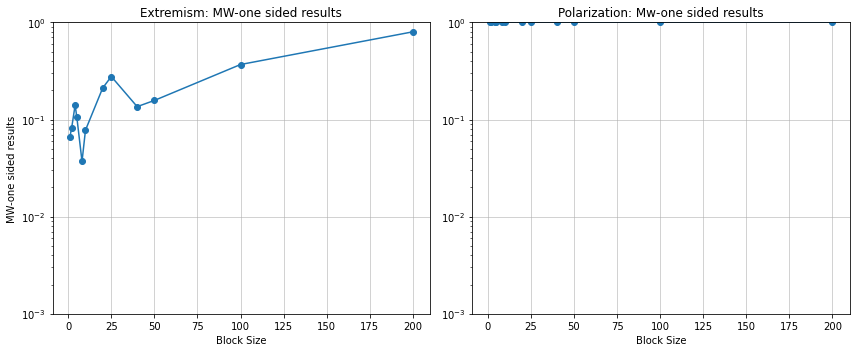

Significance rates per block size:
--------------------------------------------------


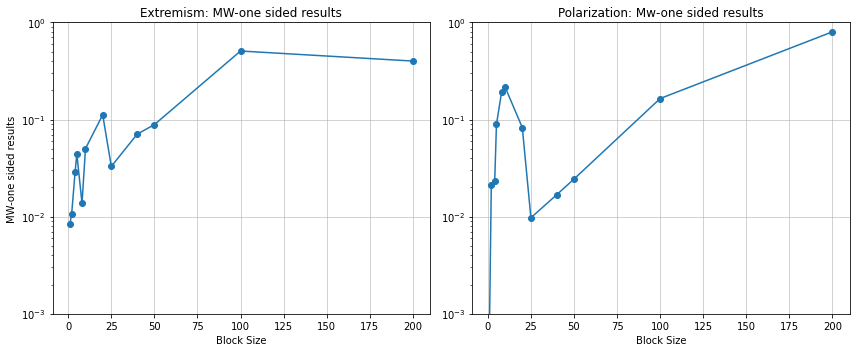

Significance rates per block size:
--------------------------------------------------


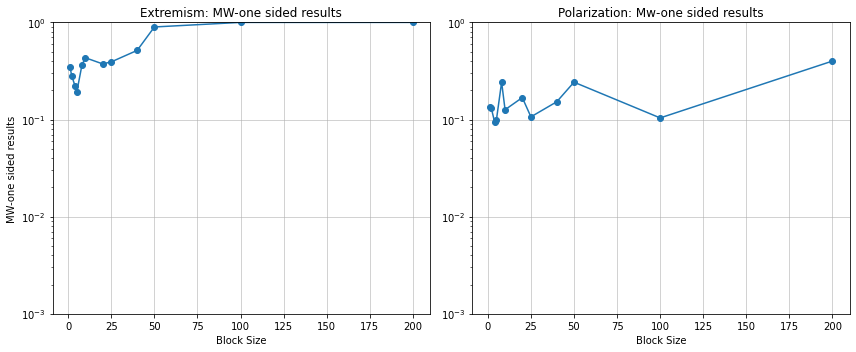

Significance rates per block size:
--------------------------------------------------


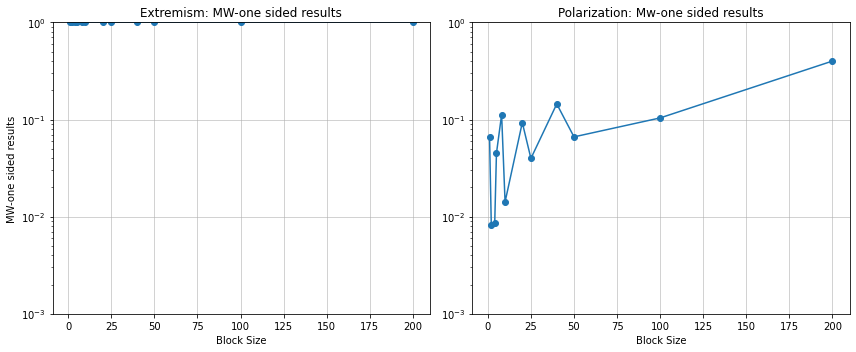

In [28]:
for topic in range(1,4+1):
    MW_TO_PLOTS(*T2MWDATA[topic])